# Defect detection pipeline

Does super-resolving a low-resolution capture improve automated defect detection? Every method reconstructs the same LR test split at the HR frame size, and every row is classified with the one fine-tuned VGG16.

Thirteen rows are compared, and every figure reads them in the same order: the LR baseline, the four interpolations, the four advanced classic algorithms, the three learned models (SRCNN, EDSR, ESRGAN) and the HR ceiling. The eleven reconstructions all produce RGB images at 478x478, which is the regime the classifier was trained on.

A single classifier scores every row, references included, which is what makes the comparison readable: a difference between two rows is a difference between the images, never between two models fitted separately. The two references sit at the ends of every figure and bracket the reconstructions, and the ceiling is what turns an absolute accuracy into a readable one: a method at 91 % means something different if HR reaches 93 % than if it reaches 99 %.

The LR baseline is classified at its native 239x239 with no resampling, so it aggregates 16 voting patches against the 81 of every other row and shows the object at twice the apparent scale the classifier was trained on. Rescaling it would equalise the frame but would add an interpolation step that is not part of the capture. The gap between the baseline and an SR row is therefore not due to resolution alone, and has to be read with that in mind.

Requires `4_srcnn`, `5_edsr`, `6_esrgan` and `8_vgg16` to have been run.

In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from srlib.constants import CLASS_LABELS_PATH, HR_ROOT, LR_ROOT
from srlib.dataset.loading import load_defect_detection_pipeline_dataset
from srlib.defect_detection.pipeline import DefectDetectionPipeline
from srlib.model_registry import print_available_runs

c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

## Load the test split

The same split the classifier was trained against, so the test images were never seen during training.

In [2]:
(
    X_LR_train, X_HR_train, y_train,
    X_LR_val, X_HR_val, y_val,
    X_LR_test, X_HR_test, y_test,
) = load_defect_detection_pipeline_dataset(HR_ROOT, LR_ROOT, CLASS_LABELS_PATH)

print(f"LR splits -> train: {X_LR_train.shape}, val: {X_LR_val.shape}, test: {X_LR_test.shape}")
print(f"HR splits -> train: {X_HR_train.shape}, val: {X_HR_val.shape}, test: {X_HR_test.shape}")
print(f"y splits  -> train: {y_train.shape}, val: {y_val.shape}, test: {y_test.shape}")


 Detection pipeline dataset | full frames
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  frames    LR 239x239 | HR 478x478
  test      160 images, the split the pipeline scores
  done in 6.7s

LR splits -> train: (574, 239, 239, 3), val: (64, 239, 239, 3), test: (160, 239, 239, 3)
HR splits -> train: (574, 478, 478, 3), val: (64, 478, 478, 3), test: (160, 478, 478, 3)
y splits  -> train: (574,), val: (64,), test: (160,)


## Run the pipeline

Leave a run as `None` to take the most recent checkpoint of that model, or pin a timestamp to reproduce an older comparison.

In [3]:
print_available_runs()

SRCNN: 1 run(s)
  - 20260917_001731 (latest)
EDSR: 1 run(s)
  - 20260916_190338 (latest)
ESRGAN: 1 run(s)
  - 20260915_175433 (latest)
VGG16: 1 run(s)
  - 20260916_000014 (latest)


In [4]:
pipeline = DefectDetectionPipeline(
    X_LR_test=X_LR_test,
    X_HR_test=X_HR_test,
    y_test=y_test,
    srcnn_run=None,
    edsr_run=None,
    esrgan_run=None,
    vgg16_run=None,
)

sr_images, labels, confidences = pipeline.run()

Resolved runs
  SRCNN   20260917_001731
  EDSR    20260916_190338
  ESRGAN  20260915_175433
  VGG16   20260916_000014
  HR frame size: 478 x 478
Loading models
Loaded pretrained model from c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260917_001731\SRCNN_20260917_001731.h5
Loaded pretrained model from c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260916_190338\EDSR_x2_20260916_190338.h5
- Generator loaded from: c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_generator_x2_20260915_175433.h5
- Discriminator loaded from: c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_discriminator_x2_202

  SRCNN                    18.06s


  EDSR                     19.12s


  ESRGAN                   51.08s


  Bilinear                  0.20s


...

  Freq-extrapolation       14.14s  accuracy=0.9375


  SRCNN                    13.79s  accuracy=0.8187


  EDSR                     13.67s  accuracy=0.8438


  ESRGAN                   13.75s  accuracy=0.9875


  HR                       13.77s  accuracy=1.0000
Predictions done in 178.04s

Pipeline finished in 302.18s


## Confusion matrices

One matrix per method, in reading order: the LR baseline, the classic families, the learned models and the HR ceiling.

(<Figure size 1800x2500 with 15 Axes>,
 array([[<Axes: title={'center': 'LR Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Bilinear Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Bicubic Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>],
        [<Axes: title={'center': 'Area Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Lanczos Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Back-Projection Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>],
        [<Axes: title={'center': 'Non-Local Means Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Edge-guided Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Freq-extrapolation Confusion Mat

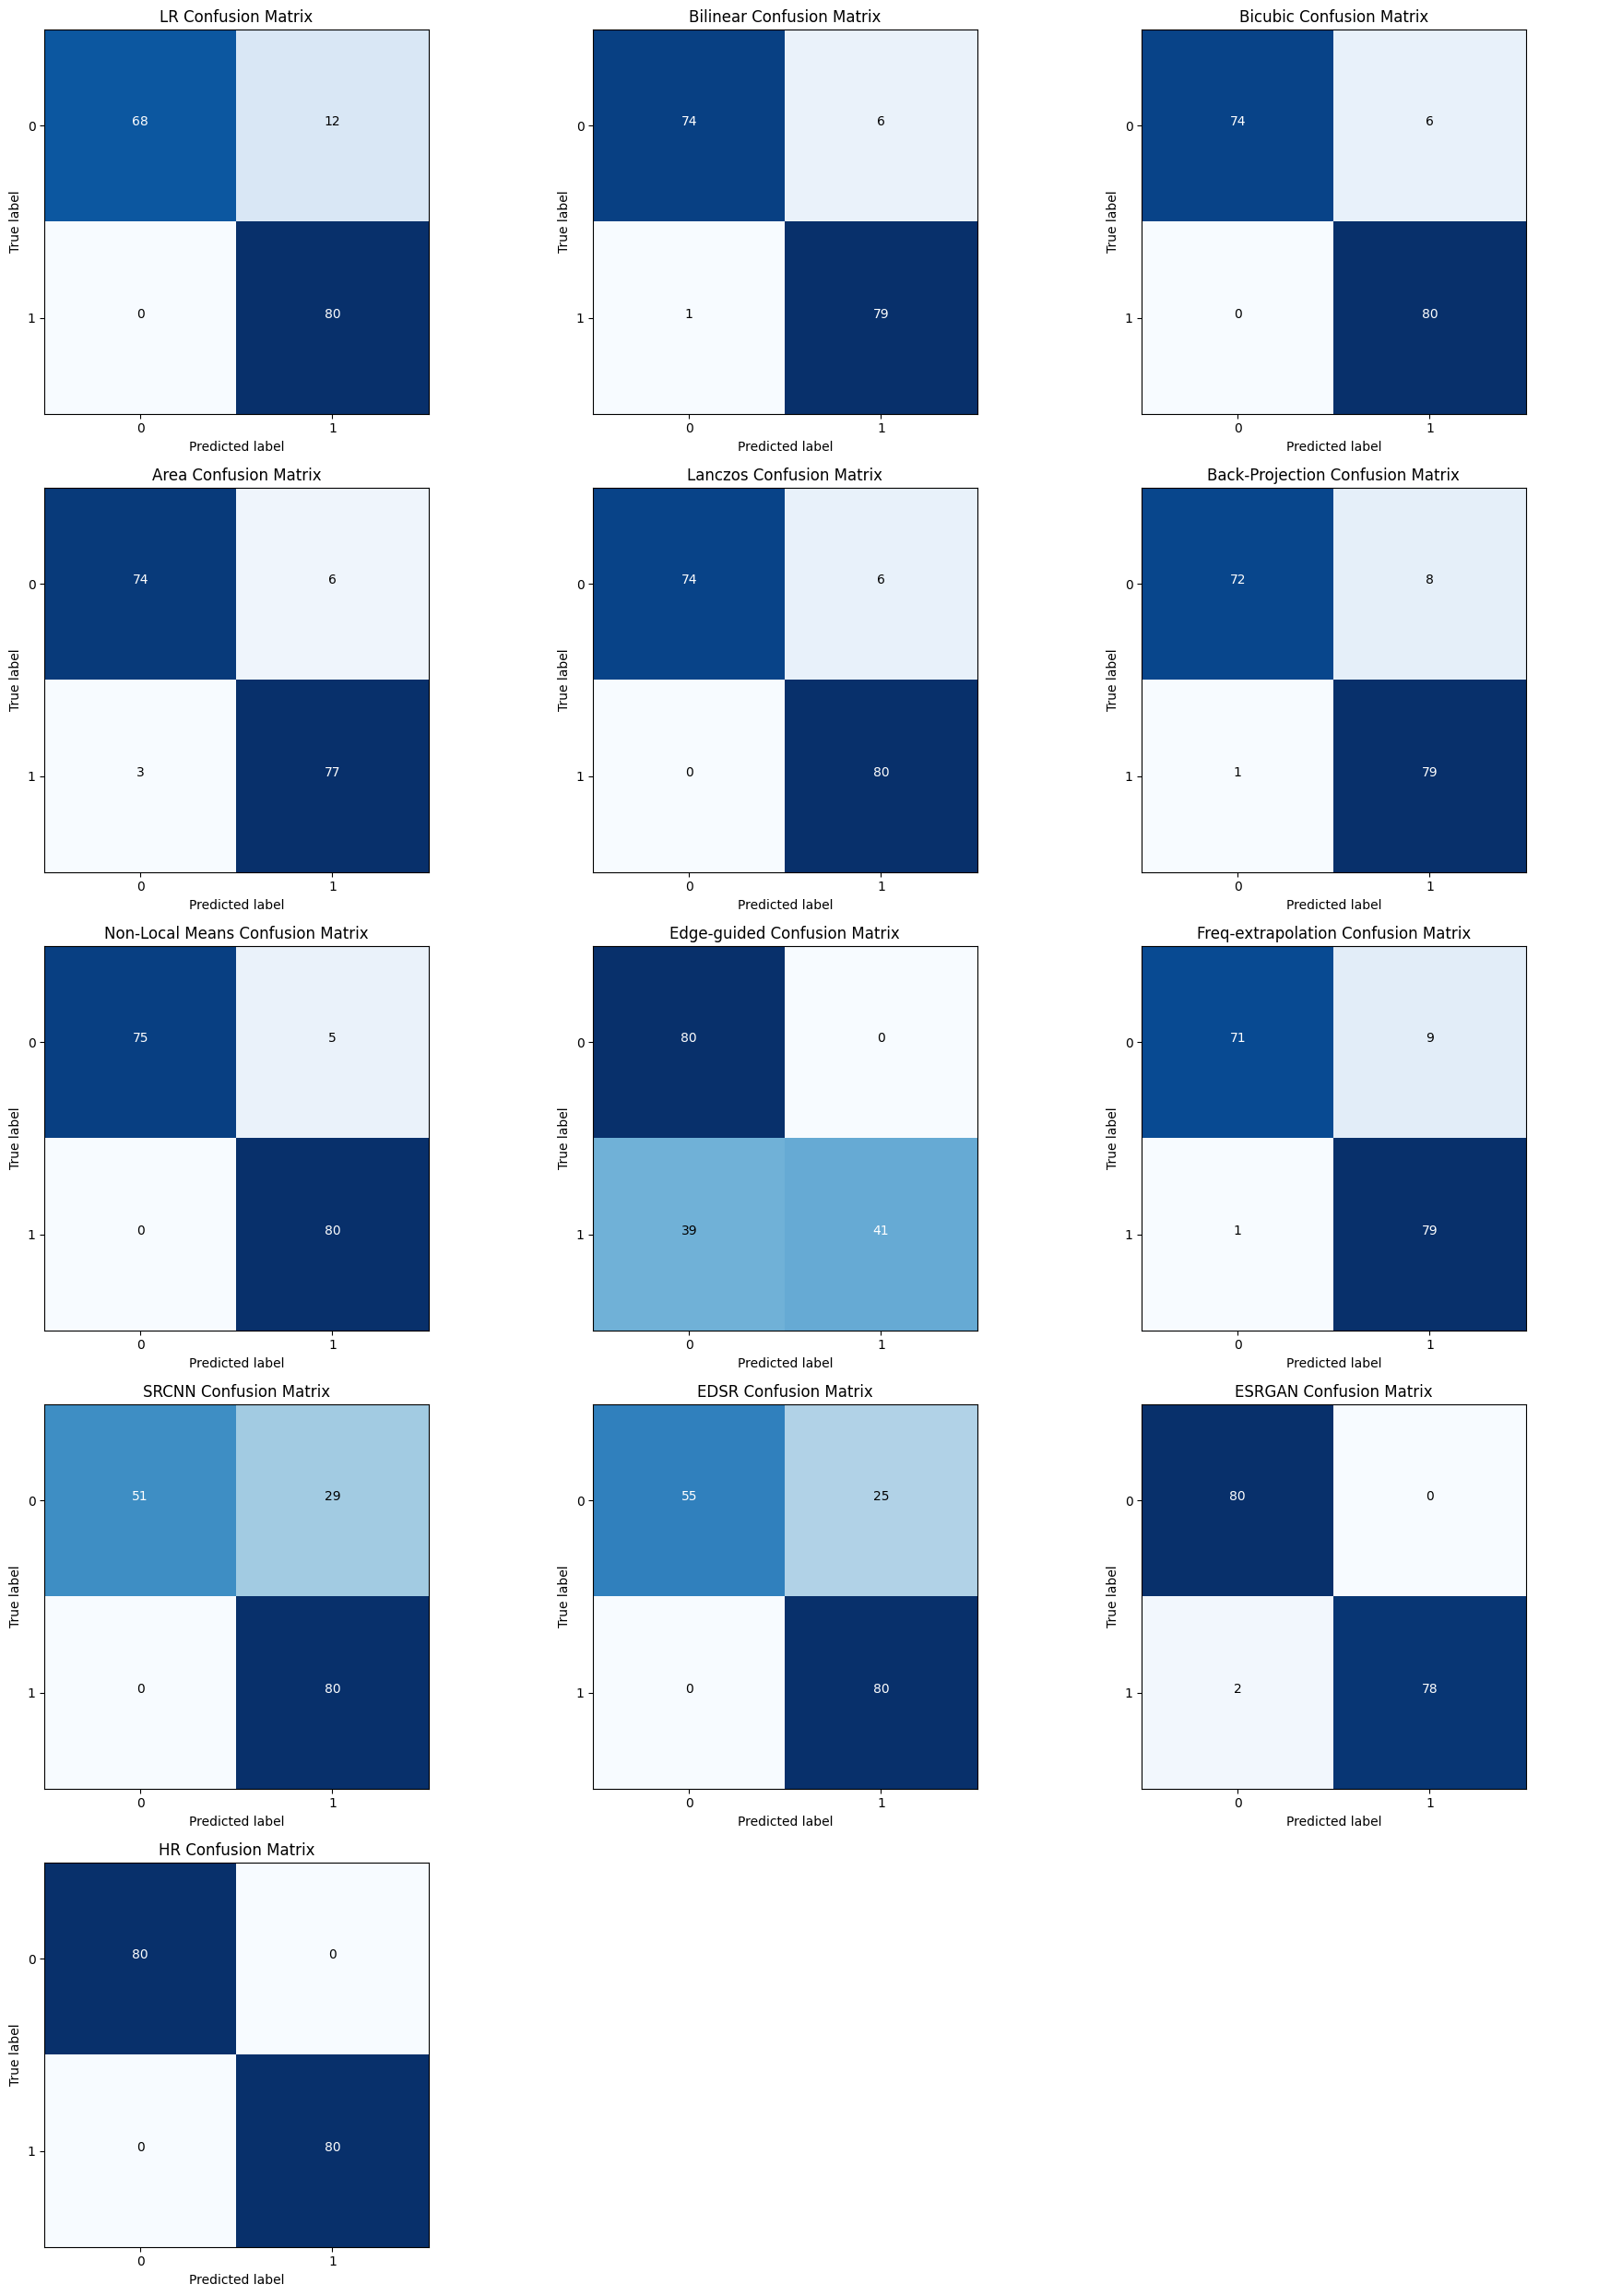

In [5]:
pipeline.plot_confusion_matrices()

## Classification report

Accuracy, macro recall and both F1 aggregates, plus the same scores resolved per class. The dataset is imbalanced, so macro F1 is the figure to read rather than accuracy.

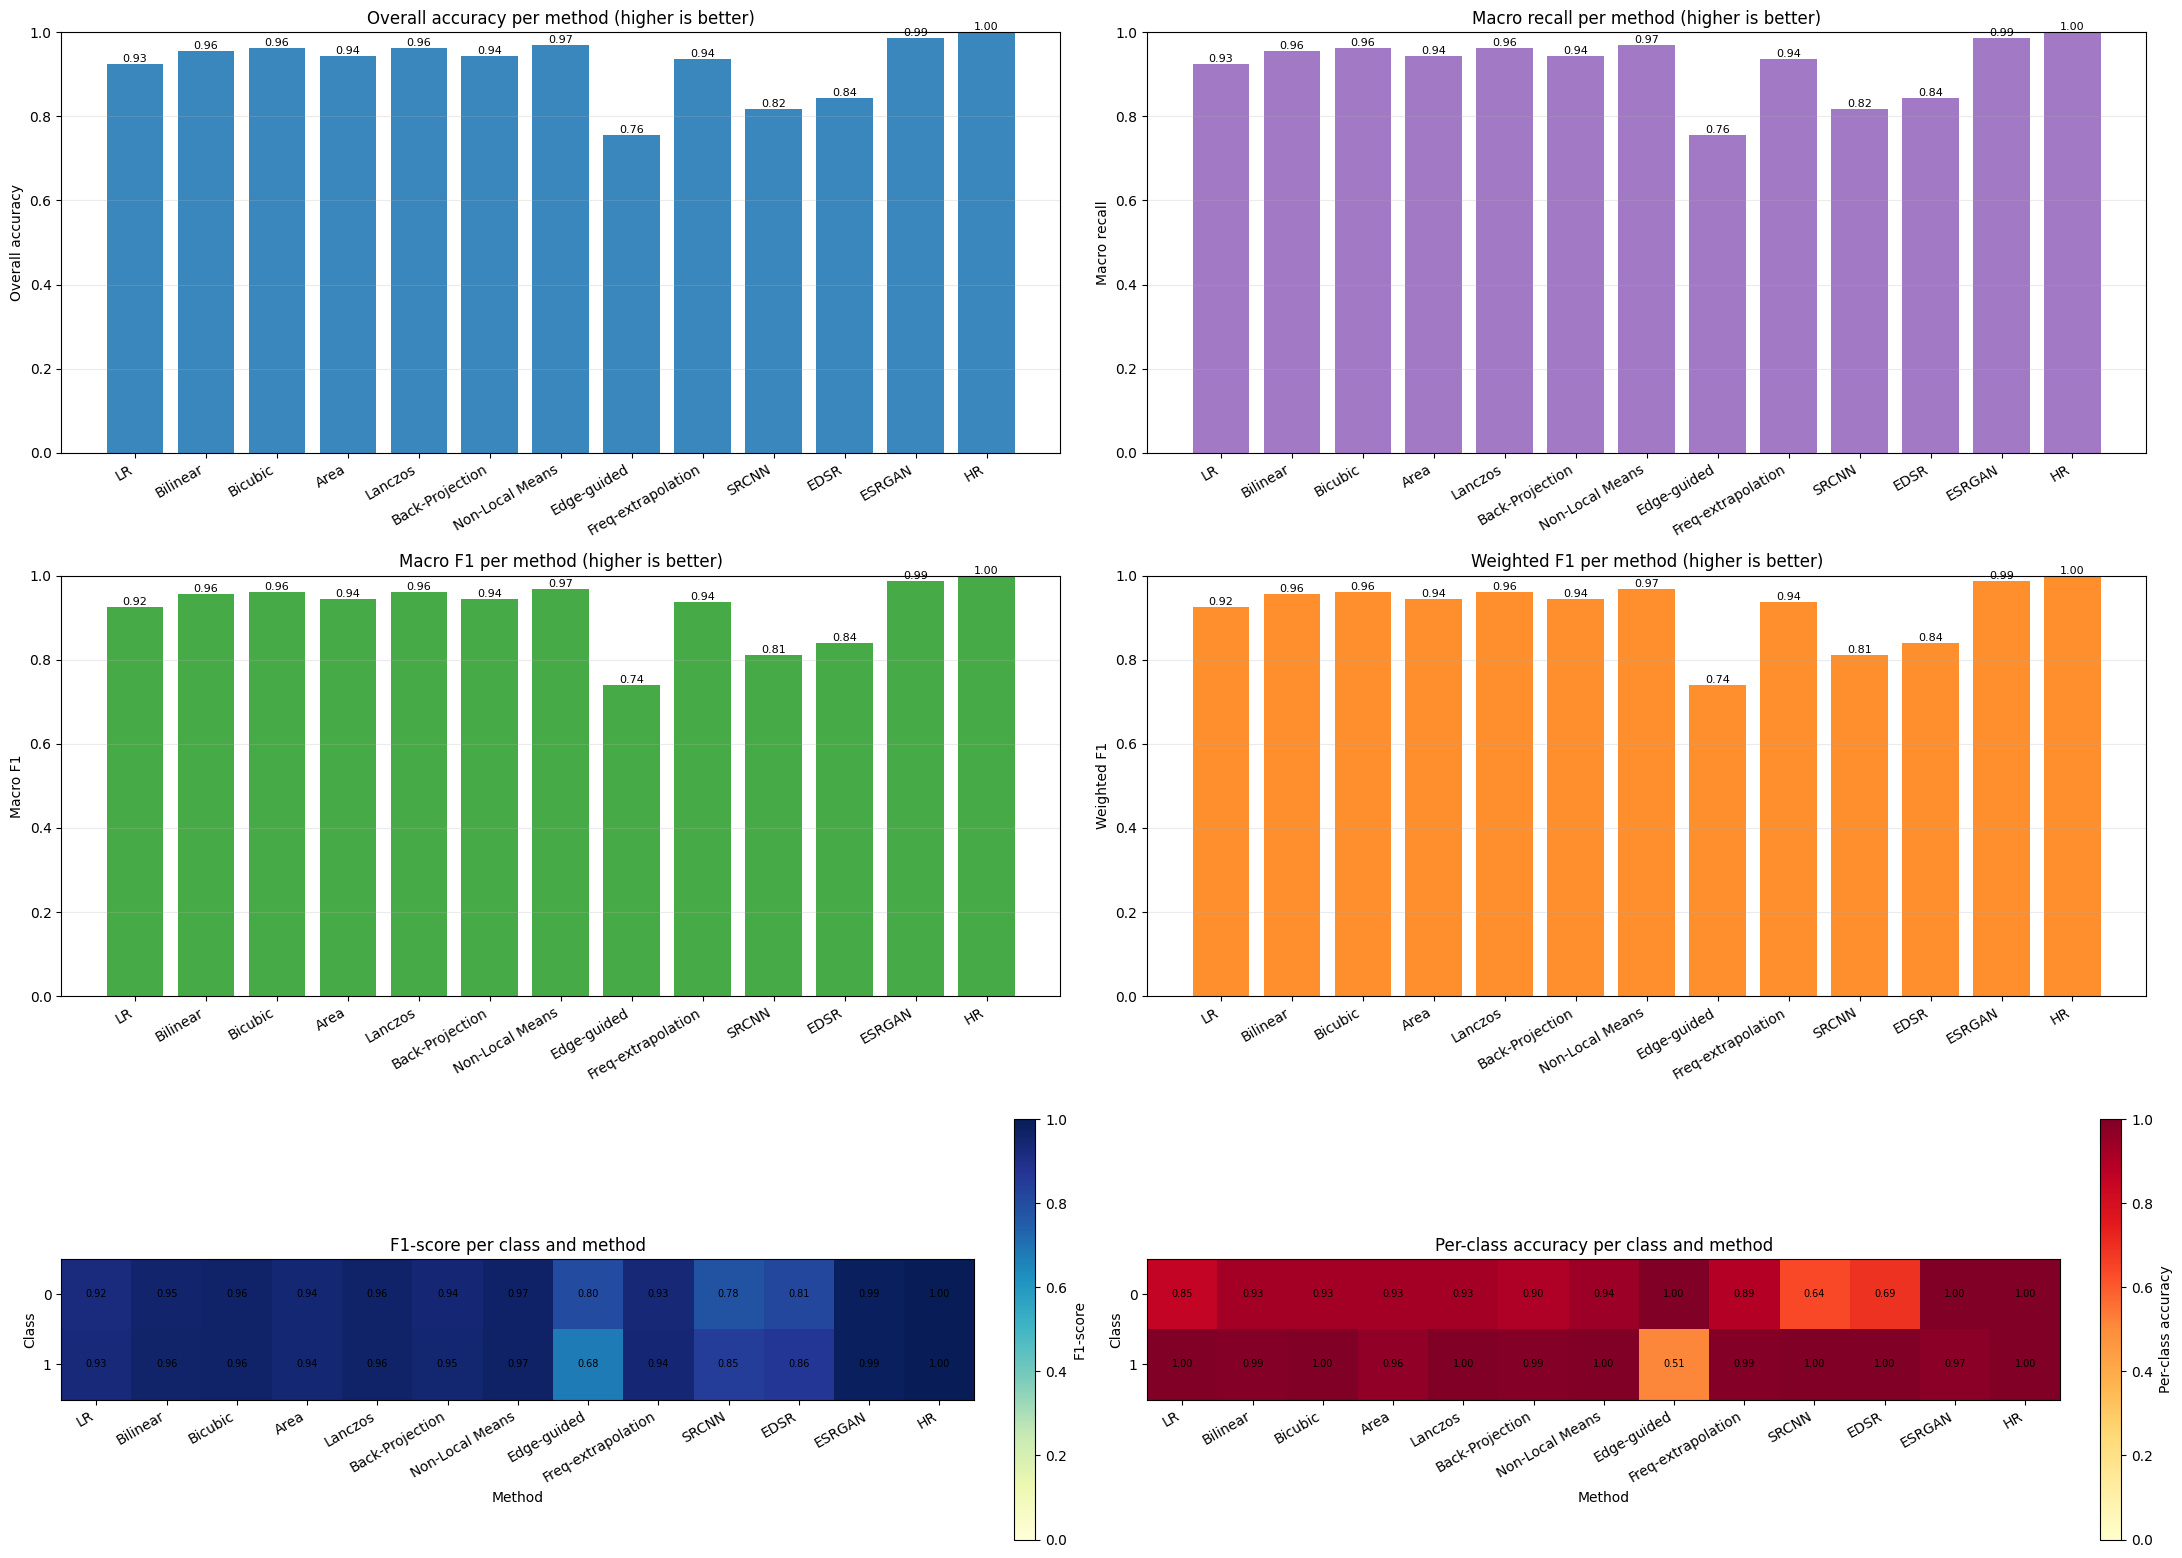

In [6]:
fig, axes, report_metrics = pipeline.plot_classification_reports()

## Confidence

Global mean confidence, the same split into correct and wrong predictions, and the error rate. The three together are what tell whether a method is confidently wrong.

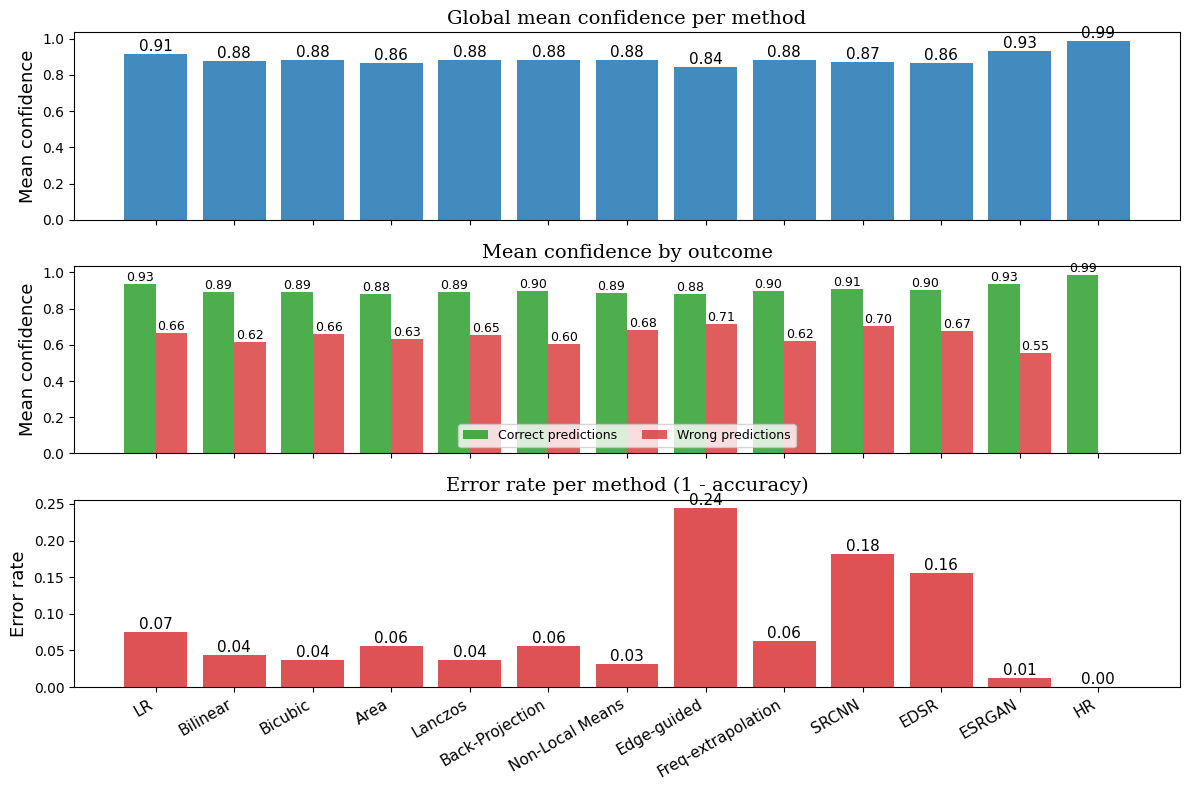

In [7]:
fig, axes, confidence_metrics = pipeline.plot_confidence()

## Qualitative comparison

Every reconstruction of a single test image with the prediction it produced. Change `index` to inspect another sample.

(<Figure size 750x1250 with 15 Axes>,
 array([[<Axes: title={'center': 'LR (Pred: 0, Conf: 1.00)'}>,
         <Axes: title={'center': 'Bilinear (Pred: 0, Conf: 0.98)'}>,
         <Axes: title={'center': 'Bicubic (Pred: 0, Conf: 0.97)'}>],
        [<Axes: title={'center': 'Area (Pred: 0, Conf: 0.97)'}>,
         <Axes: title={'center': 'Lanczos (Pred: 0, Conf: 0.97)'}>,
         <Axes: title={'center': 'IBP (Pred: 0, Conf: 0.96)'}>],
        [<Axes: title={'center': 'NLM (Pred: 0, Conf: 0.97)'}>,
         <Axes: title={'center': 'EGI (Pred: 0, Conf: 1.00)'}>,
         <Axes: title={'center': 'FDE (Pred: 0, Conf: 0.96)'}>],
        [<Axes: title={'center': 'SRCNN (Pred: 0, Conf: 0.73)'}>,
         <Axes: title={'center': 'EDSR (Pred: 0, Conf: 0.92)'}>,
         <Axes: title={'center': 'ESRGAN (Pred: 0, Conf: 1.00)'}>],
        [<Axes: title={'center': 'HR (Pred: 0, Conf: 1.00)'}>, <Axes: >,
         <Axes: >]], dtype=object))

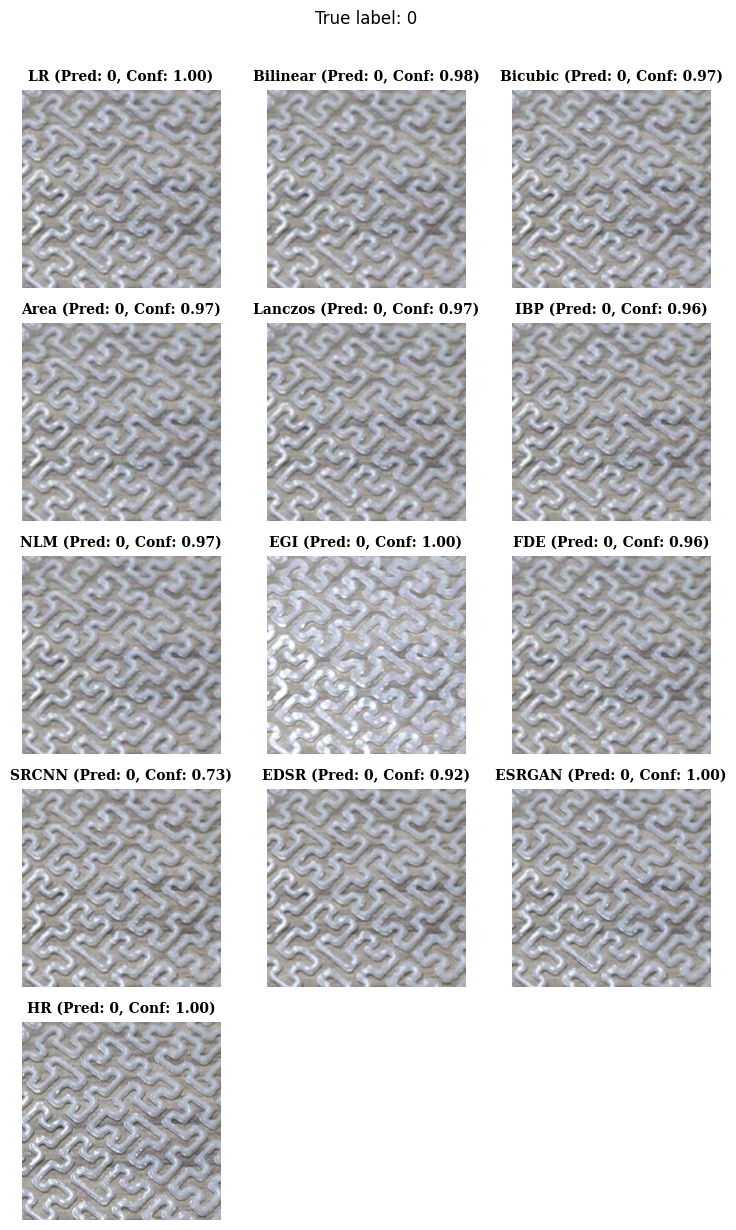

In [14]:
pipeline.plot_sample_predictions(index=35)

Time and memory of the learned models are reported in notebook 7, measured over training and over the test evaluation. Reconstructing a frame patch by patch is a cost of this pipeline, not of the models, so it is not attributed to them.